# **Lab 2 WDI**
 
### Phân tích sự phát triển kinh tế - xã hội - môi trường của các quốc gia bằng dữ liệu WDI trong thời kỳ trước và sau covid-19 2018-1024, từ đó tìm ra xu hướng tăng trưởng, sự khác biệt giữa các nhóm nước, và mối quan hệ giữa các chỉ số phát triển quan trọng.

In [92]:
### import thư viện ở đây
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter


In [93]:
### Lấy dữ liệu ở đây
sea = pd.read_csv('./datafile/southEastAsiaDataFinal.csv')

In [94]:
sea.head(10)

,Country Name,Country Code,Series Name,Series Code,2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Cambodia,KHM,GDP (current US$),NY.GDP.MKTP.CD,33145892168.8958,36685356407.7206,34818073901.4851,36790163687.4421,39994532959.6074,42335646895.7984,46352647037.2406
1,Cambodia,KHM,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,8.77622376224463,7.93695013588524,-3.55572193406549,3.08984284148661,5.12990110773977,5.00733043811898,5.97510939607335
2,Cambodia,KHM,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,7.43177030242717,6.58272364852731,-4.96368199399319,1.57862051550094,3.74000920039251,3.66847775428445,4.68384949204055
3,Cambodia,KHM,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1884.28374817086,2008.32094006706,1908.63427518336,1938.76436741728,2011.27433313262,2085.05748462122,2182.71843902341
4,Cambodia,KHM,GDP (constant 2015 US$),NY.GDP.MKTP.KD,30665817313.8491,33099747942.811,31922812945.0881,32909177695.673,34597385966.8314,36329791405.1421,38500536184.9646
5,Cambodia,KHM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,..,0.499,0.172,0.396,..,0.256,..
6,Cambodia,KHM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,0.129,0.119,0.172,0.396,0.245,0.256,0.254
7,Cambodia,KHM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2.45908515380146,1.94257500833107,2.9402951426397,2.92073477592949,5.34370264895437,2.12746796594194,0.808042016536654
8,Cambodia,KHM,"Inflation, GDP deflator (annual %)",NY.GDP.DEFL.KD.ZG,3.81658094506807,2.79255741070172,-0.824281402832511,2.64573403501885,3.48890016581984,1.01760752524498,2.35376209735443
9,Cambodia,KHM,"Inflation, GDP deflator: linked series (annual %)",NY.GDP.DEFL.KD.ZG.AD,3.81658094506807,2.79255741070172,-0.824281402832511,2.64573403501885,3.48890016581984,1.01760752524498,2.35376209735443


In [95]:
sea.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   209 non-null    object
 1   Country Code   207 non-null    object
 2   Series Name    207 non-null    object
 3   Series Code    207 non-null    object
 4   2018 [YR2018]  207 non-null    object
 5   2019 [YR2019]  207 non-null    object
 6   2020 [YR2020]  207 non-null    object
 7   2021 [YR2021]  207 non-null    object
 8   2022 [YR2022]  207 non-null    object
 9   2023 [YR2023]  207 non-null    object
 10  2024 [YR2024]  207 non-null    object
dtypes: object(11)
memory usage: 18.3+ KB


In [96]:
year_cols = [    "2024 [YR2024]",
    "2023 [YR2023]",
    "2022 [YR2022]",
    "2021 [YR2021]",
    "2020 [YR2020]",
    "2019 [YR2019]",
    "2018 [YR2018]"
]

sea_long = sea.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)


In [97]:
# Extract year
sea_long["Year"] = sea_long["Year"].str.extract(r"(\d{4})")
sea_long["Year"] = pd.to_numeric(sea_long["Year"], errors="coerce")

# Convert Value to numeric, invalid values become NaN
sea_long["Value"] = pd.to_numeric(sea_long["Value"], errors="coerce")


In [98]:
sea_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  1463 non-null   object 
 1   Country Code  1449 non-null   object 
 2   Series Name   1449 non-null   object 
 3   Series Code   1449 non-null   object 
 4   Year          1484 non-null   int64  
 5   Value         1223 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 69.7+ KB



### Thành: Phân tích xu hướng kinh tế trong giai đoạn trước và sau covid từ 2018-2024

Mức độ duy giảm và tốc độ phục hồi GDP của các quốc gia Đông Nam Á trong giai đoạn 2018-2024 phản ánh như thế nào về khả năng chống chịu trước cú sốc Covid-19 ? 

Đánh giá tính bền vững của phục hồi của các quốc gia Đông Nam Á sau giai đoạn covid-19?

Các động lực tăng trưởng kinh tế của các quốc gia Đông Nam Á đã thay đổi như thế nào trước, trong và sau COVID-19?

In [99]:
def format_billions(x, pos):
    return f"{x/1e9:.0f}B"

def format_thousands(x, pos):
    return f"{x/1e3:.0f}K"

def format_percent(x, pos):
    return f"{x:.0f}%"

In [123]:
def get_indicator_data(indicator_code):
    temp = sea_long[sea_long["Series Code"] == indicator_code].copy()
    pivot = temp.pivot(index="Year", columns="Country Name", values="Value")
    return pivot

def get_indicator_country_year(indicator_code):
    temp = sea_long[sea_long["Series Code"] == indicator_code].copy()
    return temp

def add_value_labels(ax, fmt="{:.2f}", rotation=0, fontsize=9):
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom",
                        rotation=rotation, fontsize=fontsize,
                        xytext=(0, 3), textcoords="offset points")

In [125]:
indicators = {
    "NY.GDP.MKTP.CD": "GDP",
    "NY.GDP.MKTP.KD.ZG": "GDP growth (%)",
    "NY.GDP.PCAP.CD": "GDP per capita (current US$)",
    "NE.CON.TOTL.ZS": "Final consumption expenditure (% GDP)",
    "NE.GDI.TOTL.ZS": "Gross capital formation (% GDP)",
    "NE.EXP.GNFS.ZS": "Exports of goods and services (% GDP)",
    "NE.IMP.GNFS.ZS": "Imports of goods and services (% GDP)",
    "BX.KLT.DINV.WD.GD.ZS": "FDI net inflows (% GDP)",
    "ST.INT.RCPT.XP.ZS": "International tourism receipts (% GDP)",
    "NV.IND.TOTL.ZS": "Industry, value added (% GDP)",
    "NV.SRV.TOTL.ZS": "Services, value added (% GDP)",
    "SL.UEM.TOTL.ZS": "Unemployment rate (%)",
    "FP.CPI.TOTL.ZG": "Inflation, consumer prices (annual %)"
}
fdi = get_indicator_data("BX.KLT.DINV.WD.GD.ZS")
tourism = get_indicator_data("ST.INT.XPND.CD")
industry = get_indicator_data("NV.IND.TOTL.ZS")
services = get_indicator_data("NV.SRV.TOTL.ZS")
unemployment = get_indicator_data("SL.UEM.TOTL.ZS")
gdp_growth = get_indicator_data("NY.GDP.MKTP.KD.ZG")

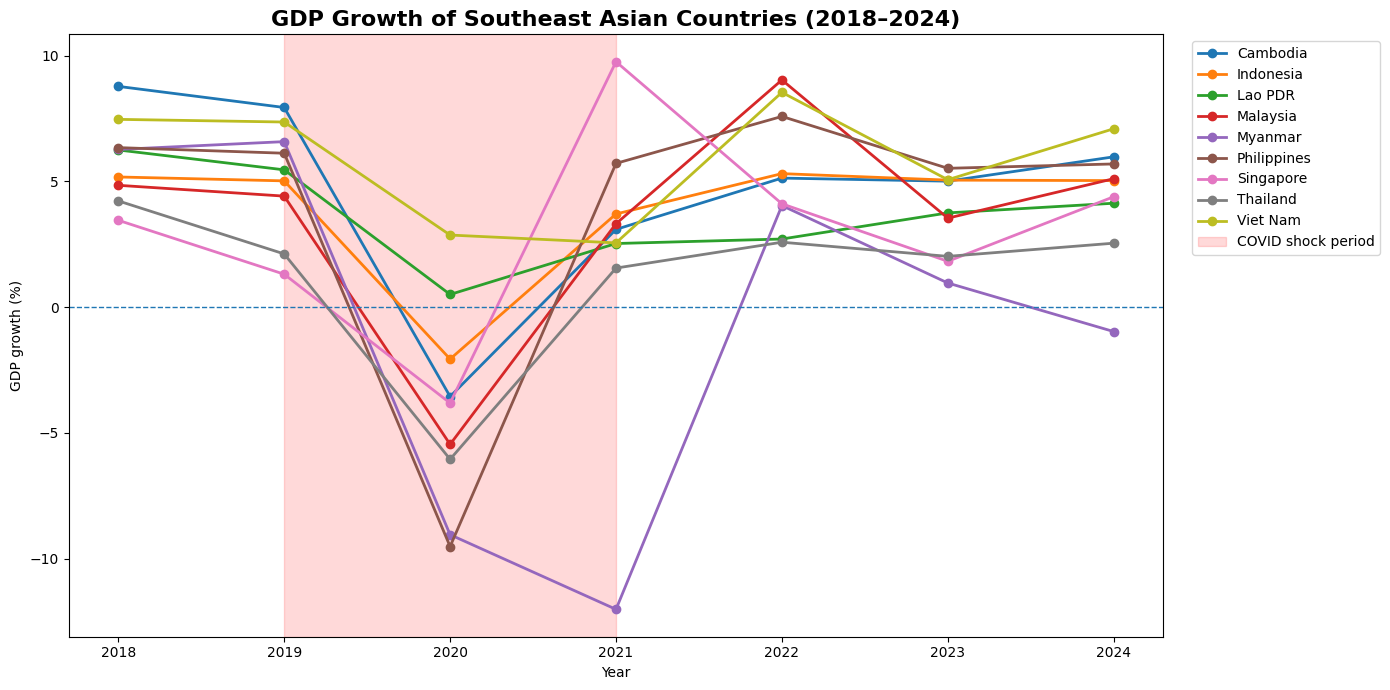

In [126]:
### Biểu đồ ở đây
gdp_growth = get_indicator_data("NY.GDP.MKTP.KD.ZG")

plt.figure(figsize=(14, 7))
for country in gdp_growth.columns:
    plt.plot(gdp_growth.index, gdp_growth[country], marker="o", linewidth=2, label=country)

plt.axvspan(2019, 2021, alpha=0.15, color="red", label="COVID shock period")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("GDP Growth of Southeast Asian Countries (2018–2024)", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("GDP growth (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

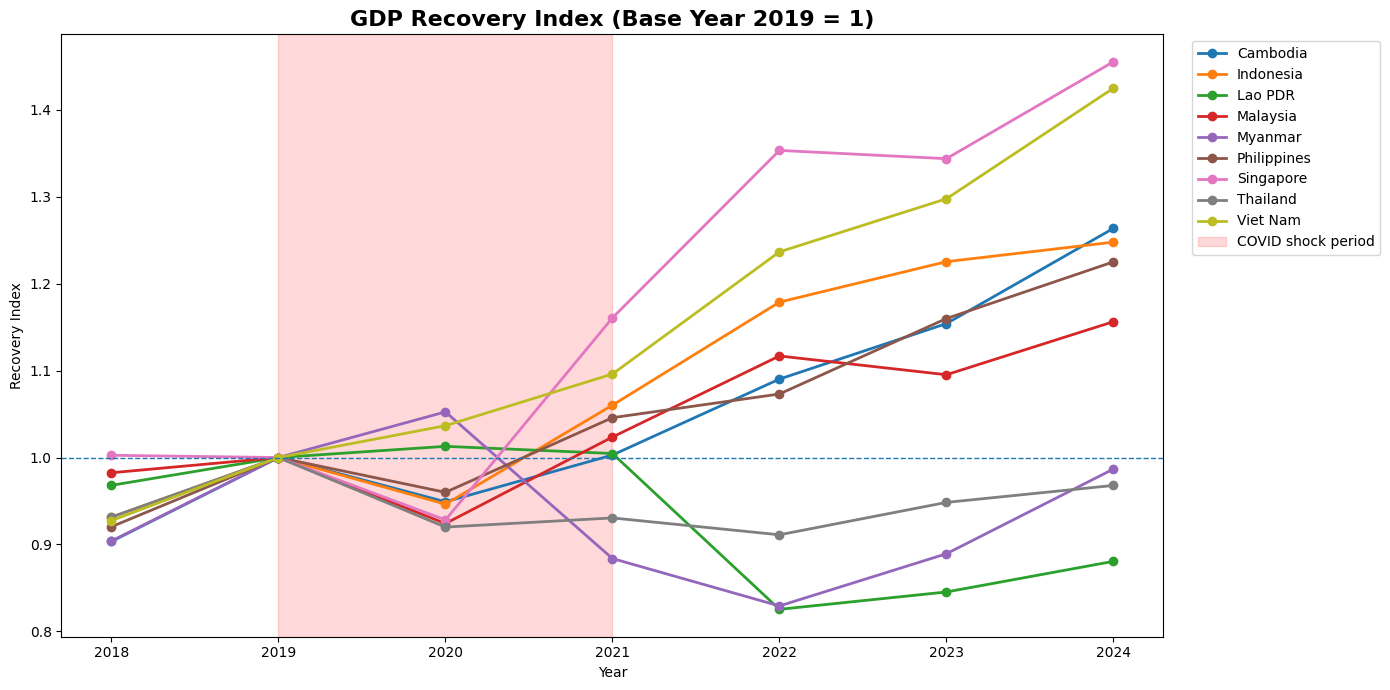

In [129]:
gdp = get_indicator_data("NY.GDP.MKTP.CD")

recovery_index = gdp.divide(gdp.loc[2019], axis=1)

plt.figure(figsize=(14, 7))
for country in recovery_index.columns:
    plt.plot(recovery_index.index, recovery_index[country], marker="o", linewidth=2, label=country)

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axvspan(2019, 2021, alpha=0.15, color="red", label="COVID shock period")

plt.title("GDP Recovery Index (Base Year 2019 = 1)", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Recovery Index")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_3440\1617422482.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm")  # Choose a colormap (e.g., coolwarm, viridis, plasma)
C:\Users\asus\AppData\Local\Temp\ipykernel_3440\1617422482.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


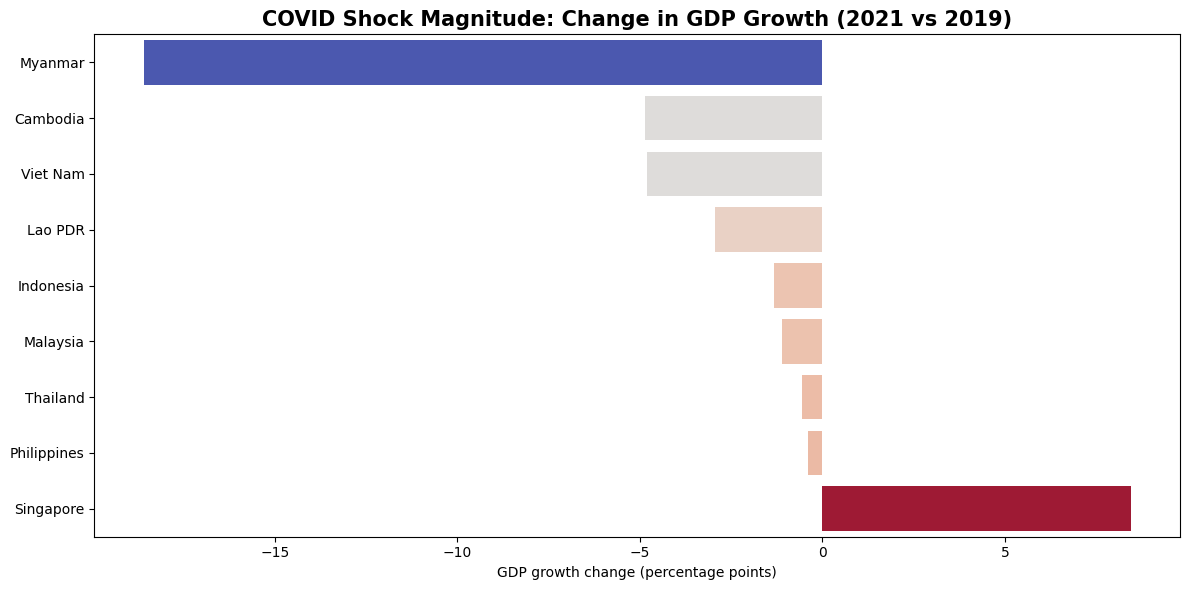

In [139]:
from matplotlib.colors import Normalize
from matplotlib import cm

# Normalize the Shock_Magnitude values to create a gradient
norm = Normalize(vmin=shock_df["Shock_Magnitude"].min(), vmax=shock_df["Shock_Magnitude"].max())
cmap = cm.get_cmap("coolwarm")  # Choose a colormap (e.g., coolwarm, viridis, plasma)

# Map each value to a color
shock_df["Color"] = shock_df["Shock_Magnitude"].apply(lambda x: cmap(norm(x)))

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=shock_df, 
    x="Shock_Magnitude", 
    y="Country", 
    palette=shock_df.set_index("Country")["Color"].to_dict()
)

plt.title("COVID Shock Magnitude: Change in GDP Growth (2021 vs 2019)", fontsize=15, weight="bold")
plt.xlabel("GDP growth change (percentage points)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Câu 2:

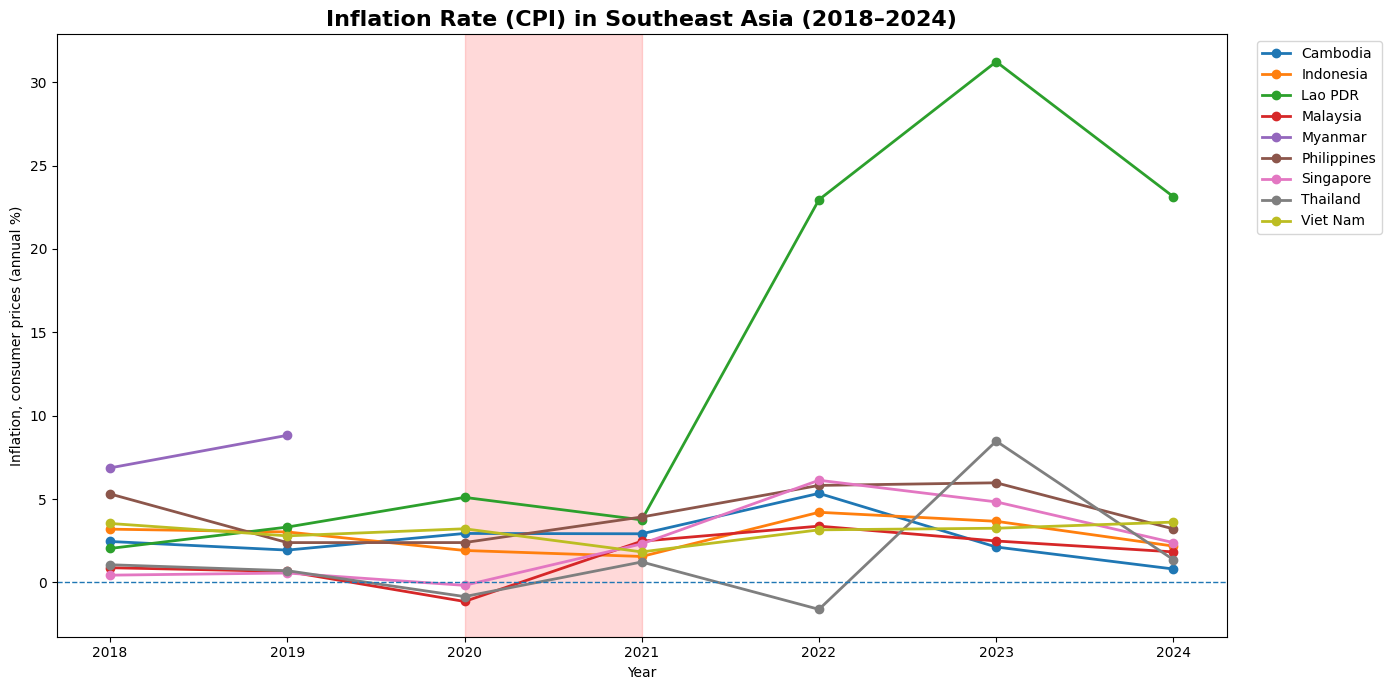

In [104]:
inflation = get_indicator_data("FP.CPI.TOTL.ZG")

plt.figure(figsize=(14, 7))
for country in inflation.columns:
    plt.plot(inflation.index, inflation[country], marker="o", linewidth=2, label=country)

plt.axvspan(2020, 2021, alpha=0.15, color="red")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Inflation Rate (CPI) in Southeast Asia (2018–2024)", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Inflation, consumer prices (annual %)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

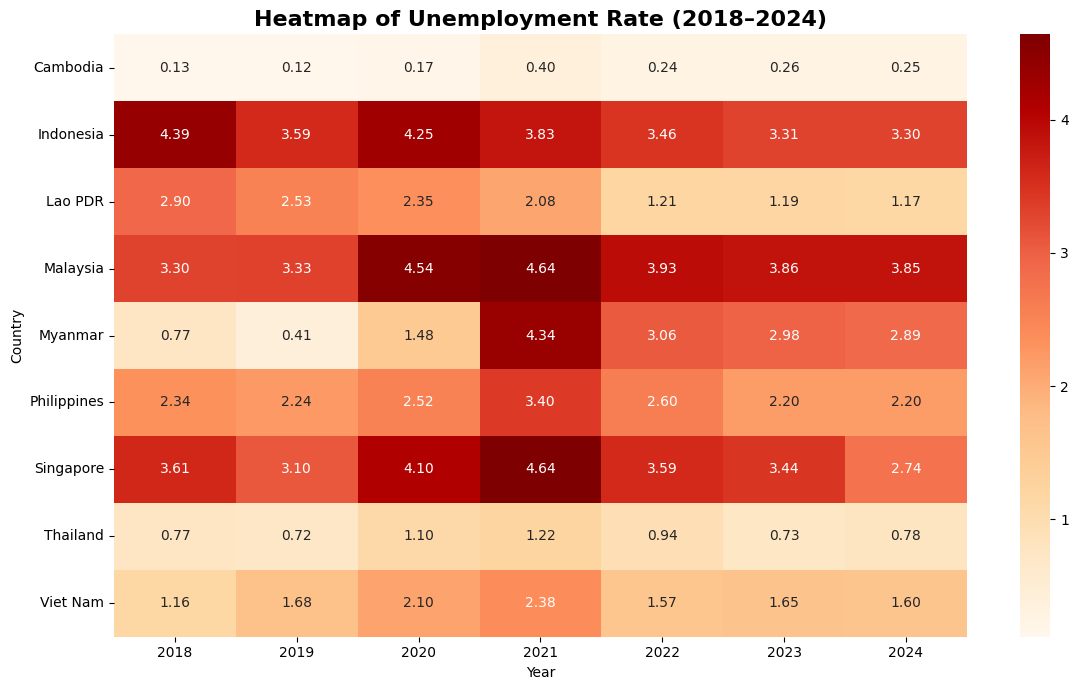

In [120]:
plt.figure(figsize=(12, 7))
sns.heatmap(unemployment.T, annot=True, fmt=".2f", cmap="OrRd")
plt.title("Heatmap of Unemployment Rate (2018–2024)", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

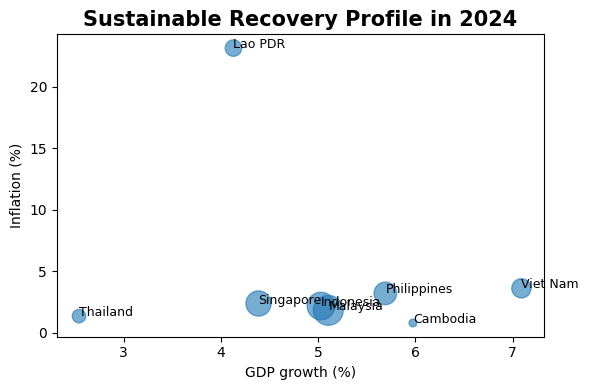

In [119]:
bubble_df = pd.DataFrame({
    "Country": gdp_growth.columns,
    "GDP Growth 2024": gdp_growth.loc[2024].values,
    "Inflation 2024": inflation.loc[2024].values,
    "Unemployment 2024": unemployment.loc[2024].values
}).dropna()

plt.figure(figsize=(6, 4))
plt.scatter(
    bubble_df["GDP Growth 2024"],
    bubble_df["Inflation 2024"],
    s=bubble_df["Unemployment 2024"] * 120,
    alpha=0.6
)

for _, row in bubble_df.iterrows():
    plt.text(row["GDP Growth 2024"], row["Inflation 2024"], row["Country"], fontsize=9)

plt.title("Sustainable Recovery Profile in 2024", fontsize=15, weight="bold")
plt.xlabel("GDP growth (%)")
plt.ylabel("Inflation (%)")
plt.tight_layout()
plt.show()

### Câu 3

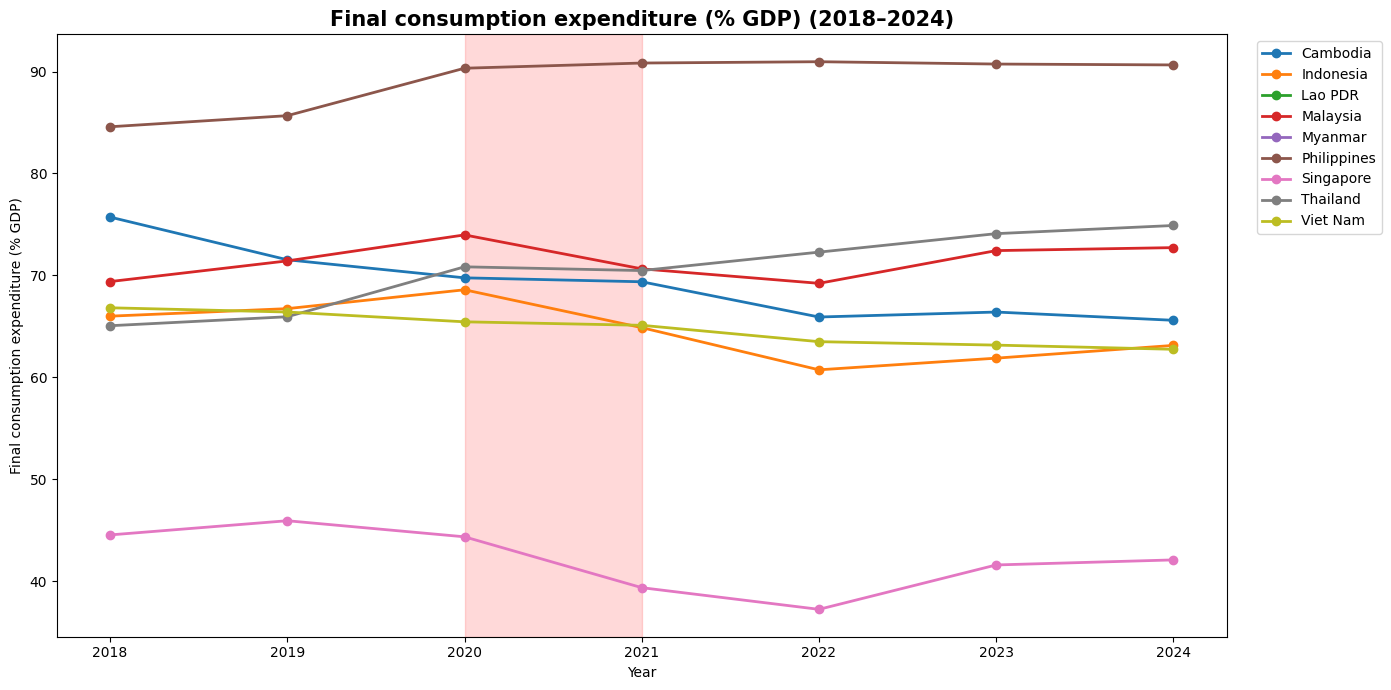

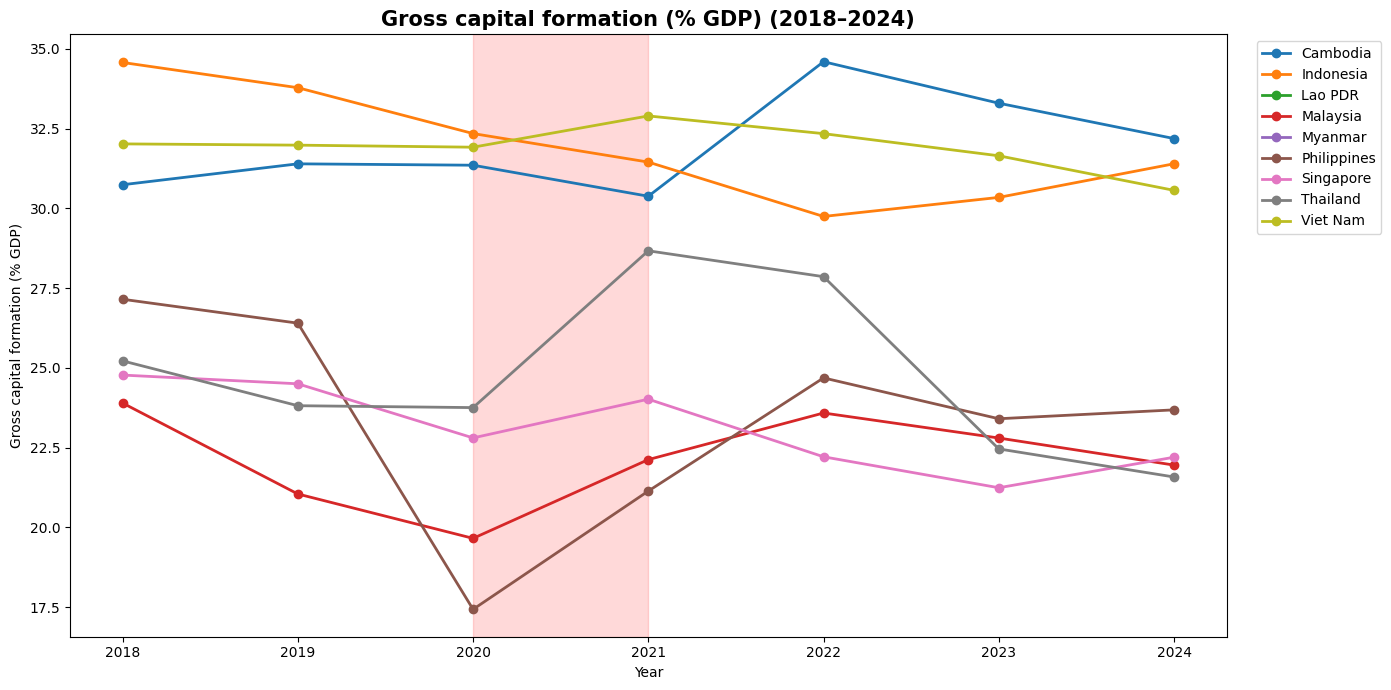

In [121]:
### C
indicator_list = [
    ("NE.CON.TOTL.ZS", "Final consumption expenditure (% GDP)"),
    ("NE.GDI.TOTL.ZS", "Gross capital formation (% GDP)"),
]

for code, title in indicator_list:
    temp = get_indicator_data(code)
    
    plt.figure(figsize=(14, 7))
    for country in temp.columns:
        plt.plot(temp.index, temp[country], marker="o", linewidth=2, label=country)
    
    plt.axvspan(2020, 2021, alpha=0.15, color="red")
    plt.title(title + " (2018–2024)", fontsize=15, weight="bold")
    plt.xlabel("Year")
    plt.ylabel(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [109]:
exports = get_indicator_data("NE.EXP.GNFS.ZS")
imports = get_indicator_data("NE.IMP.GNFS.ZS")
selected_countries = [
    "Viet Nam", "Thailand", "Malaysia", "Indonesia",
    "Singapore", "Philippines", "Cambodia", "Myanmar", "Lao PDR"
]


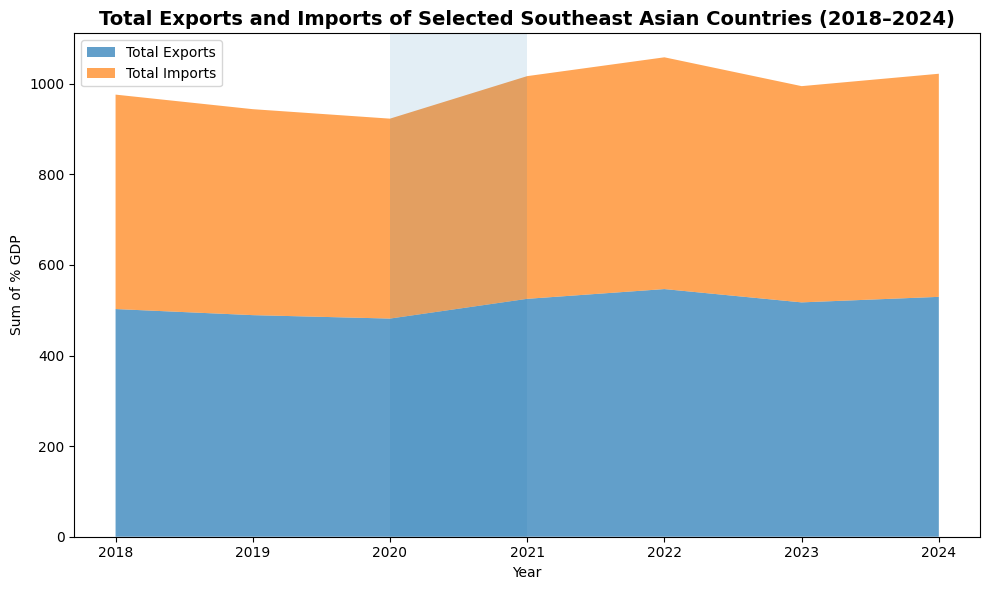

In [110]:
export_total = exports[selected_countries].sum(axis=1)
import_total = imports[selected_countries].sum(axis=1)

plt.figure(figsize=(10, 6))
plt.stackplot(
    export_total.index,
    export_total,
    import_total,
    labels=["Total Exports", "Total Imports"],
    alpha=0.7
)

plt.axvspan(2020, 2021, alpha=0.12)
plt.title("Total Exports and Imports of Selected Southeast Asian Countries (2018–2024)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Sum of % GDP")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

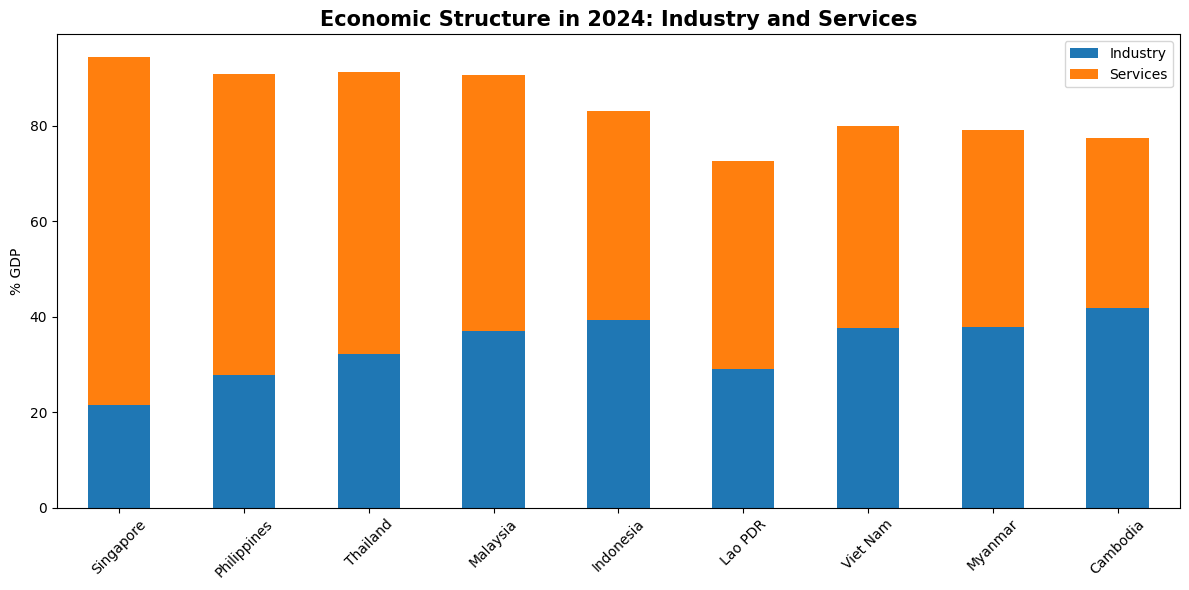

In [112]:
structure_2024 = pd.DataFrame({
    "Industry": industry.loc[2024],
    "Services": services.loc[2024]
}).fillna(0)

structure_2024 = structure_2024.sort_values("Services", ascending=False)

structure_2024.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Economic Structure in 2024: Industry and Services", fontsize=15, weight="bold")
plt.xlabel("")
plt.ylabel("% GDP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

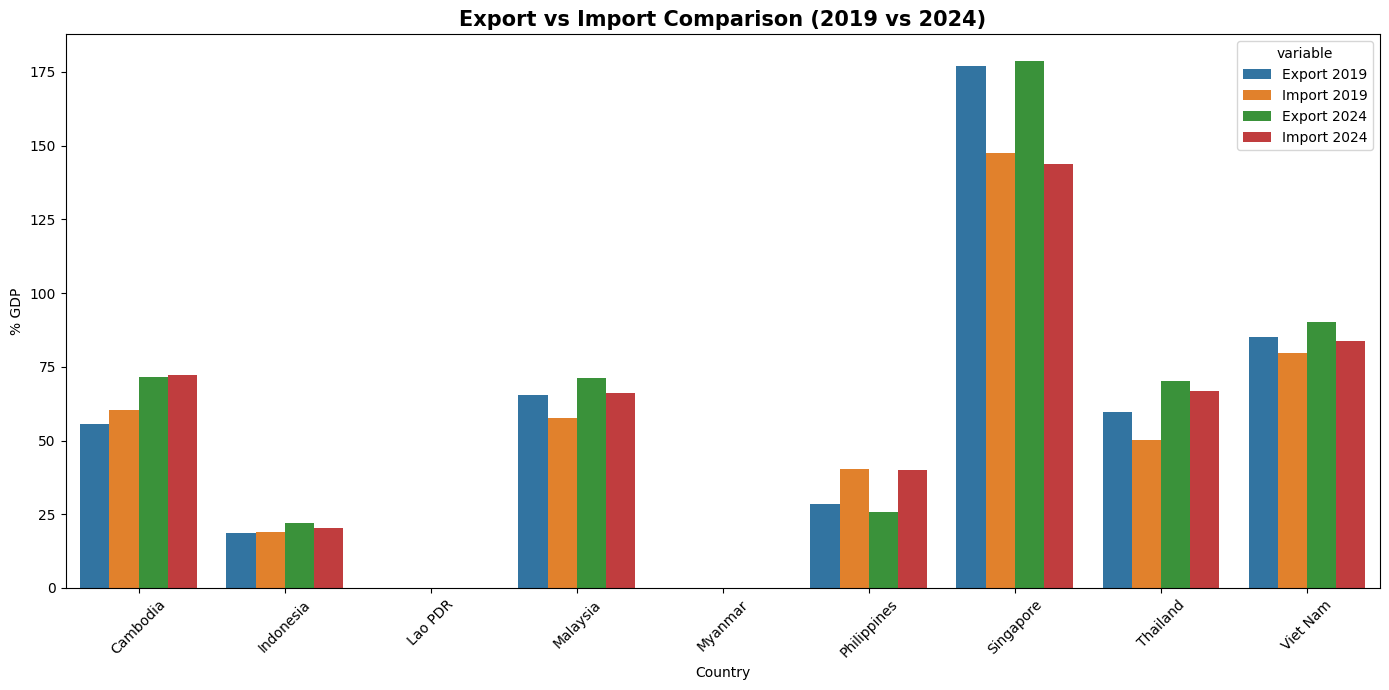

In [113]:
compare_trade = pd.DataFrame({
    "Country": exports.columns,
    "Export 2019": exports.loc[2019].values,
    "Import 2019": imports.loc[2019].values,
    "Export 2024": exports.loc[2024].values,
    "Import 2024": imports.loc[2024].values
})

compare_melt = compare_trade.melt(id_vars="Country")

plt.figure(figsize=(14, 7))
sns.barplot(data=compare_melt, x="Country", y="value", hue="variable")

plt.title("Export vs Import Comparison (2019 vs 2024)", fontsize=15, weight="bold")
plt.ylabel("% GDP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Đoàn: So sánh giữa các quốc gia/nhóm quốc gia

So sánh tỷ lệ đô thị hóa giữa các khu vực trên thế giới tại các mốc năm 2000, 2010 và 2020 để nhận diện khu vực đô thị hóa nhanh nhất.

So sánh tuổi thọ trung bình giữa các nhóm thu nhập quốc gia trong năm gần nhất có dữ liệu đầy đủ để đánh giá chênh lệch chất lượng sống.

So sánh tỷ lệ biết chữ hoặc tỷ lệ nhập học giữa các khu vực để xác định khu vực có mức phát triển giáo dục cao hơn.

In [114]:
### Code biểu đồ ở đây

### Lộc: Phân tích tổng hợp và khám phá quan hệ chỉ số

Phân tích tương quan giữa nhiều chỉ số phát triển quan trọng như GDP/người, tuổi thọ, tỷ lệ đô thị hóa, phát thải CO2, chi tiêu giáo dục để tìm các mối quan hệ nổi bật.

Phân cụm hoặc phân nhóm mô tả các quốc gia theo bộ chỉ số phát triển chính trong năm 2020 để nhận diện các nhóm quốc gia có đặc điểm tương đồng.

Xác định các quốc gia có sự thay đổi mạnh nhất về chỉ số phát triển trong giai đoạn 2000–2020 để rút ra những trường hợp điển hình về tăng trưởng hoặc suy giảm.

In [115]:
### Code biểu đồ ở đây

### Ngọc: Phân tích xã hội – giáo dục – y tế

Phân tích mối quan hệ giữa chi tiêu cho giáo dục và tỷ lệ biết chữ của các quốc gia trong giai đoạn 2015–2020 để xem đầu tư giáo dục có đi kèm kết quả tích cực hay không.

Phân tích mối quan hệ giữa chi tiêu y tế và tuổi thọ trung bình của các quốc gia để đánh giá tác động của đầu tư y tế đến sức khỏe dân số.

Phân tích xu hướng tỷ lệ tử vong trẻ em theo thời gian tại một số quốc gia đại diện để xem mức cải thiện y tế qua các năm.


In [116]:
### Code biểu đồ ở đây

### Duy: Phân tích môi trường – năng lượng
Phân tích xu hướng phát thải CO2 của các quốc gia hoặc khu vực trong giai đoạn 2000–2020 để xác định nơi gia tăng phát thải mạnh nhất.

Phân tích mối quan hệ giữa GDP bình quân đầu người và phát thải CO2 bình quân đầu người để xem tăng trưởng kinh tế có đi kèm áp lực môi trường hay không.

Phân tích tỷ lệ sử dụng năng lượng tái tạo giữa các quốc gia trong năm gần nhất để xác định nhóm nước chuyển đổi xanh tốt hơn.


In [117]:
### Code biểu đồ ở đây